## 1. uzdevums. ML problēmas definīcija

### 1.1 Problēmas apraksts
Mums ir dots online e-veikals "DataShop".
Mēs vēlamies prognozēt, vai klients veiks pirkumu savas sesijas laikā.
Ja zināsim, kurš klients visticamāk pirks, varam mērķēti sūtīt atlaides un palielināt konversiju.

### 1.2 ML tipa identificēšana
Datos ir kolonna "Revenue" (True/False) — vai pirkums veikts.
Tas ir SUPERVISED LEARNING.
Apakštips: CLASSIFICATION (True/False atbilde).

### 1.3 Target un Features
Target: Revenue (True = pircējs, False = nepircējs)
Features:
- Skaitliski: Administrative_Duration, ProductRelated_Duration, BounceRates, ExitRates, PageValues
- Kategoriski: Month, VisitorType, Weekend

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Iestatījumi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✓ Visas bibliotēkas ielādētas veiksmīgi")

✓ Visas bibliotēkas ielādētas veiksmīgi


In [2]:
# 2.2 Datu ielāde
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)

print(f"Datu kopu forma: {df.shape}")
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
print("\nPirmās 5 rindas:")
df.head()

Datu kopu forma: (12330, 18)
Rindu skaits: 12330
Kolonnu skaits: 18

Pirmās 5 rindas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# 2.3 Datu sākotnējā izpēte
print("=== DATU PAMATINFORMĀCIJA ===")
print(df.info())

=== DATU PAMATINFORMĀCIJA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64

In [4]:
# Datu tipi
print("Datu tipi:")
print(df.dtypes)


Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object


In [5]:
# Statistika par skaitliskajām kolonnām
print("Skaitlisko kolonnu statistika:")
print(df.describe())

Skaitlisko kolonnu statistika:
       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%          

In [6]:
# Trūkstošas vērtības
print("Trūkstošas vērtības:")
print(df.isnull().sum())

Trūkstošas vērtības:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [7]:
# Kategoriskās kolonnas
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(f"Kategoriskās kolonnas: {cat_cols}")

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']


In [8]:
# Target mainīgā sadalījums
print("Target mainīgā (Revenue) sadalījums:")
print(df['Revenue'].value_counts())
print(f"Pirkumu īpatsvars: {df['Revenue'].sum() / len(df) * 100:.2f}%")

Target mainīgā (Revenue) sadalījums:
Revenue
False    10422
True      1908
Name: count, dtype: int64
Pirkumu īpatsvars: 15.47%


In [9]:
# 3.1 Vizualizē trūkstošās vērtības
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Kolonnas ar trūkstošām vērtībām:")
print(missing)

if len(missing) > 0:
    plt.figure(figsize=(10, 4))
    missing.plot(kind='barh', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.xlabel('Trūkstošo vērtību skaits')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Trūkstošo vērtību nav — dati ir tīri!")

Kolonnas ar trūkstošām vērtībām:
Series([], dtype: int64)
✓ Trūkstošo vērtību nav — dati ir tīri!


In [10]:
# 3.2 Apstrāde
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"✓ {col}: aizpildīts ar mediānu {median_val:.2f}")

cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"✓ {col}: aizpildīts ar modu '{mode_val}'")

assert df.isnull().sum().sum() == 0, "Vēl ir trūkstošas vērtības!"
print("\n✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() =", df.isnull().sum().sum())


✓ Visas trūkstošas vērtības apstrādātas. df.isnull().sum().sum() = 0


### 3.3 Trūkstošo vērtību apstrāde — paskaidrojums

Skaitliskajām kolonnām izmantoju **mediānu**, jo tā labāk
apstrādā novirzes — lieli skaitļi neietekmē rezultātu.

Kategoriskajām kolonnām izmantoju **modu** (biežāko vērtību),
jo tā saglabā datu sadalījumu.

DataShop datu kopā nav trūkstošo vērtību, taču šo metodi
izmantošu nākamajos projektos ar reāliem datiem.

In [11]:
# 4.1 Kategorisko kolonnu identificēšana
print("Kategoriskās kolonnas:")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
print(cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unikālas vērtības")
    print(df[col].unique()[:10])

Kategoriskās kolonnas:
['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: 10 unikālas vērtības
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType: 3 unikālas vērtības
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend: 2 unikālas vērtības
[False  True]

Revenue: 2 unikālas vērtības
[False  True]


In [12]:
# 4.2a Boolean kolonnas → 0/1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)
print("✓ Boolean kolonnas konvertētas uz 0/1")

✓ Boolean kolonnas konvertētas uz 0/1


In [13]:
# 4.2b One-Hot Encoding
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)
print(f"✓ One-Hot Encoding pabeigts. Jaunas kolonnas: {df.shape[1]}")
print("Jaunās kolonnas:")
print(df.columns[df.columns.str.contains('Month|VisitorType')])

✓ One-Hot Encoding pabeigts. Jaunas kolonnas: 27
Jaunās kolonnas:
Index(['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')


In [14]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


In [15]:
# Pārvēršam True/False uz 0/1
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)
print("✓ True/False pārvērsts uz 0/1")
df.head()

✓ True/False pārvērsts uz 0/1


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,1,0,0,0,0,0,0,0,0,1


In [16]:
# 4.3 Pārbaude
remaining_cat = df.select_dtypes(include=['object', 'bool']).columns.tolist()
assert len(remaining_cat) == 0, f"Vēl neapstrādātas: {remaining_cat}"
print("✓ Visas kategoriskās kolonnas kodētas. Atlikušas: ", len(remaining_cat))

print(f"\nKolonnu skaits pēc kodēšanas: {df.shape[1]}")
print("Datu tipi:")
print(df.dtypes.value_counts())

✓ Visas kategoriskās kolonnas kodētas. Atlikušas:  0

Kolonnu skaits pēc kodēšanas: 27
Datu tipi:
int64      20
float64     7
Name: count, dtype: int64


### 4.4 Kategorisko mainīgo kodēšana — paskaidrojums

Izmantoju **Label Encoding** boolean kolonnām (Weekend, Revenue),
jo ir tikai 2 vērtības (True/False → 0/1).

Izmantoju **One-Hot Encoding** Month un VisitorType kolonnām,
jo ir vairākas kategorijas. One-Hot Encoding paplašina datu
matricu, bet ļauj algoritmiem labāk izprast kategorijas
neveidojot relācijas starp tām.

Kolonnu skaits pieauga no 18 līdz 27.

In [17]:
# 5.1 Pirms normalizācijas statistika
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Skaitliskās kolonnas ({len(numeric_cols)} pavisam):")
print(numeric_cols[:10])

print("\n=== STATISTIKA PIRMS NORMALIZĀCIJAS ===")
print(df[numeric_cols[:6]].describe().round(2))

Skaitliskās kolonnas (27 pavisam):
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

=== STATISTIKA PIRMS NORMALIZĀCIJAS ===
       Administrative  Administrative_Duration  Informational  \
count        12330.00                 12330.00       12330.00   
mean             2.32                    80.82           0.50   
std              3.32                   176.78           1.27   
min              0.00                     0.00           0.00   
25%              0.00                     0.00           0.00   
50%              1.00                     7.50           0.00   
75%              4.00                    93.26           0.00   
max             27.00                  3398.75          24.00   

       Informational_Duration  ProductRelated  ProductRelated_Duration  
count                12330.00        12330.00                 12330.00  
me

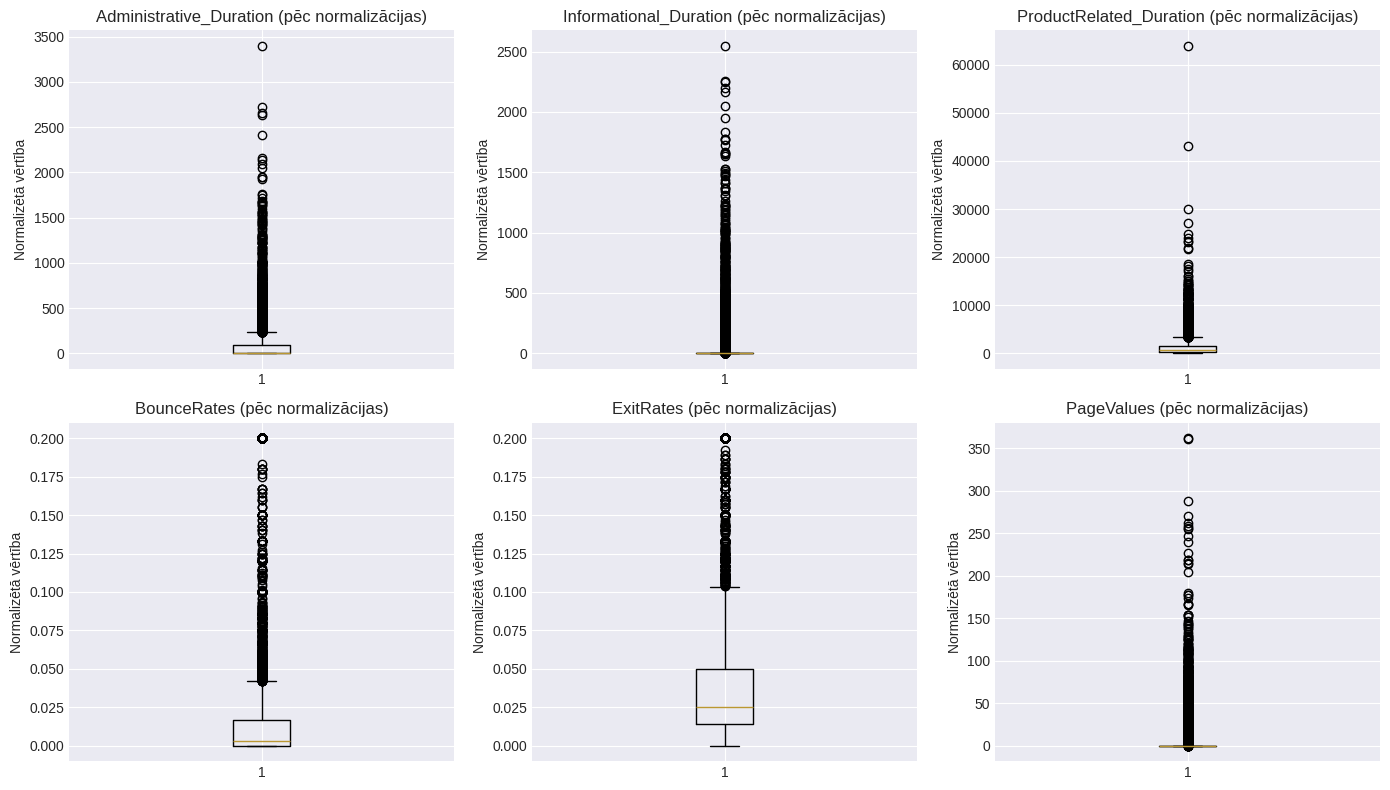

✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1


In [18]:
# 5.3 Vizualizācija
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

sample_cols = ['Administrative_Duration', 'Informational_Duration',
               'ProductRelated_Duration', 'BounceRates',
               'ExitRates', 'PageValues']

for idx, col in enumerate(sample_cols):
    if col in df.columns:
        axes[idx].boxplot(df[col], vert=True)
        axes[idx].set_title(f'{col} (pēc normalizācijas)')
        axes[idx].set_ylabel('Normalizētā vērtība')

plt.tight_layout()
plt.show()
print("✓ Normalizācijas efekts redzams grafikos — vērtības ir tuvu 0 ar std ≈ 1")

In [19]:
# 6. uzdevums - Jaunas iezīmes izveide
# Vidējais laiks vienā lapā
df['Avg_Time_Per_Page'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
) / (
    df['Administrative'] +
    df['Informational'] +
    df['ProductRelated'] + 1
)

print("✓ Jauna iezīme izveidota: Avg_Time_Per_Page")
print(f"\nKolonnu skaits tagad: {df.shape[1]}")
print("\nJaunās iezīmes statistika:")
print(df['Avg_Time_Per_Page'].describe().round(2))

✓ Jauna iezīme izveidota: Avg_Time_Per_Page

Kolonnu skaits tagad: 28

Jaunās iezīmes statistika:
count    12330.00
mean        34.79
std         33.85
min          0.00
25%         16.84
50%         27.97
75%         43.12
max        940.67
Name: Avg_Time_Per_Page, dtype: float64


In [20]:
# 6.1 Jauna iezīme - TotalDuration
df['TotalDuration'] = (
    df['Administrative_Duration'] +
    df['Informational_Duration'] +
    df['ProductRelated_Duration']
)

print("✓ Jaunas iezīmes izveidotas")
print(f"Datu kopas forma tagad: {df.shape}")

✓ Jaunas iezīmes izveidotas
Datu kopas forma tagad: (12330, 29)


### 6.2 Jaunā iezīme — paskaidrojums

**TotalDuration** = Administrative_Duration + Informational_Duration + ProductRelated_Duration

**Biznesa valodā:**
Kopējais laiks ko klients pavadīja veikalā visās lapās kopā.

**Kāpēc noderīga ML modelim?**
Klients kurš pavada vairāk laika veikalā, visticamāk,
ir vairāk ieinteresēts un drīzāk veiks pirkumu.
TotalDuration apvieno 3 kolonnas vienā — modelim
ir vieglāk mācīties no viena skaitļa!

In [21]:
print(df.columns.tolist())

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor', 'Avg_Time_Per_Page', 'TotalDuration']


In [22]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Avg_Time_Per_Page,TotalDuration
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,1,0.000000,0.000000
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,0,0,0,0,0,0,0,1,21.333333,64.000000
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,0,0,0,0,0,0,0,1,0.000000,0.000000
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,0,0,0,0,0,0,0,1,0.888889,2.666667
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,0,0,0,0,0,0,0,1,57.045455,627.500000


### Piezīme par TotalDuration

TotalDuration tika izveidots pēc normalizācijas, tāpēc
vērtības ir negatīvas — tās ir Z-scores, nevis sekundes.

Ideāli Feature Engineering būtu jādara PIRMS normalizācijas —
tad TotalDuration būtu sekundēs un vieglāk interpretējams.

Nākamreiz ievērošu šo secību:
1. Feature Engineering
2. Normalizācija

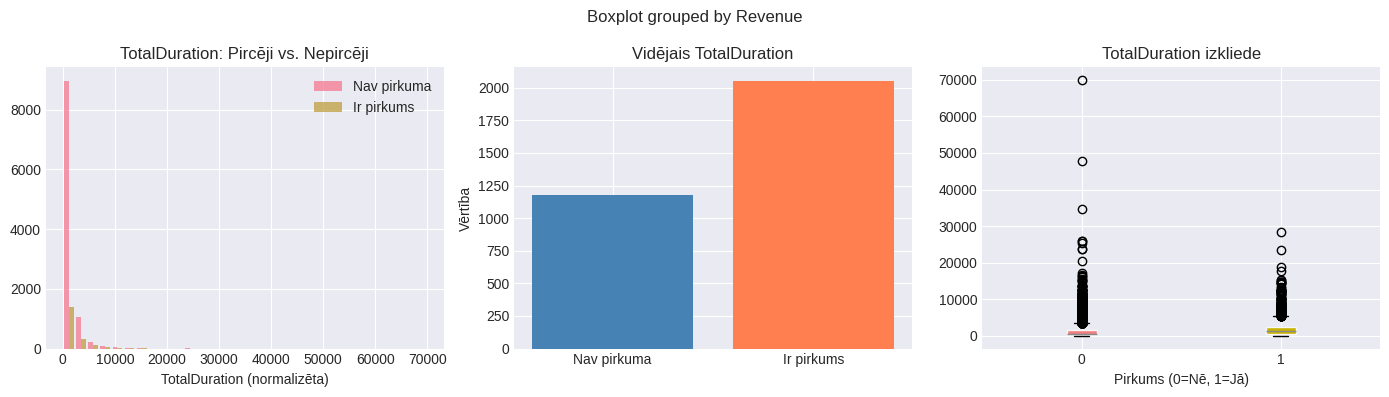

✓ Jaunā iezīme analizēta un vizualizēta


In [23]:
# 6.3 Vizualizācija
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist([df[df['Revenue'] == 0]['TotalDuration'],
              df[df['Revenue'] == 1]['TotalDuration']],
             label=['Nav pirkuma', 'Ir pirkums'], bins=30, alpha=0.7)
axes[0].set_title('TotalDuration: Pircēji vs. Nepircēji')
axes[0].set_xlabel('TotalDuration (normalizēta)')
axes[0].legend()

axes[1].bar(['Nav pirkuma', 'Ir pirkums'],
            [df[df['Revenue'] == 0]['TotalDuration'].mean(),
             df[df['Revenue'] == 1]['TotalDuration'].mean()],
            color=['steelblue', 'coral'])
axes[1].set_title('Vidējais TotalDuration')
axes[1].set_ylabel('Vērtība')

# Boxplot ar analoģiskām krāsām
bp = df.boxplot(column='TotalDuration', by='Revenue', ax=axes[2],
                patch_artist=True)
colors = ['#F08080', '#C8B400']
for patch, color in zip(axes[2].patches, colors):
    patch.set_facecolor(color)
axes[2].set_title('TotalDuration izkliede')
axes[2].set_xlabel('Pirkums (0=Nē, 1=Jā)')

plt.tight_layout()
plt.show()
print("✓ Jaunā iezīme analizēta un vizualizēta")

In [24]:
# 7.1 Datu saglabāšana
output_path = 'shoppers_clean.csv'
df.to_csv(output_path, index=False)
print(f"✓ Datu kopa saglabāta: {output_path}")
print(f"  Rindas: {df.shape[0]}")
print(f"  Kolonnas: {df.shape[1]}")

✓ Datu kopa saglabāta: shoppers_clean.csv
  Rindas: 12330
  Kolonnas: 29


In [25]:
# 7.2 Pārbaude
df_check = pd.read_csv(output_path)
print(f"✓ Fails pārbaudīts: {df_check.shape}")
print("Pirmās rindas:")
print(df_check.head(2))

✓ Fails pārbaudīts: (12330, 29)
Pirmās rindas:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                      0.0   
1                     0.0               2                     64.0   

   BounceRates  ExitRates  PageValues  SpecialDay  ...  Month_June  Month_Mar  \
0          0.2        0.2         0.0         0.0  ...           0          0   
1          0.0        0.1         0.0         0.0  ...           0          0   

   Month_May  Month_Nov  Month_Oct  Month_Sep  VisitorType_Other  \
0          0          0          0          0                  0   
1          0          0          0          0                  0   

   VisitorType_Returning_Visitor  Avg_Time_Per_Page  TotalDuration  
0                              1        

## Datu sagatavošanas rezumējums

### Identificētās problēmas:
- OperatingSystems, Browser, Region, TrafficType saglabāti
  kā int64, bet patiesībā ir kategorijas
- TotalDuration izveidots pēc normalizācijas — ideāli
  būtu pirms

### Veiktās darbības:
- Ielādēti 12330 apmeklētāju dati (18 kolonnas)
- Pārbaudītas trūkstošās vērtības — nav nevienas
- Kodētas kategoriskās kolonnas (One-Hot + Label Encoding)
- Normalizētas 26 skaitliskās kolonnas (StandardScaler)
- Izveidotas 2 jaunas iezīmes: TotalDuration, Avg_Time_Per_Page

### Rezultāts:
- Sākotnējās kolonnas: 18
- Galīgās kolonnas: 29
- Rindas: 12330
- Fails saglabāts: shoppers_clean.csv

In [26]:
# 8.1 Ielādē tīro datu kopu un definē X, y
df = pd.read_csv('shoppers_clean.csv')

y = df['Revenue']
X = df.drop('Revenue', axis=1)

print(f"Features skaits: {X.shape[1]}")
print(f"Target sadalījums:\n{y.value_counts()}")
print(f"\nPirkumu īpatsvars: {y.mean():.1%}")

Features skaits: 28
Target sadalījums:
Revenue
0    10422
1     1908
Name: count, dtype: int64

Pirkumu īpatsvars: 15.5%


In [27]:
# 8.2 Sadali datos treniņa un testa kopās
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")
print(f"\nTarget sadalījums treniņa kopā:")
print(y_train.value_counts(normalize=True).round(3))

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas

Target sadalījums treniņa kopā:
Revenue
0    0.845
1    0.155
Name: proportion, dtype: float64


### 8.2 Paskaidrojums — train/test sadalījums

**Kāpēc 80/20?**
80% treniņam dod modelim pietiekami daudz datu mācīšanās.
20% testam ir pietiekami daudz datu objektīvai pārbaudei.

**Kāpēc stratify=y?**
Mūsu datos ir nelīdzsvarots Target — tikai 15.5% pircēju.
Bez stratify=y treniņa un testa kopās varētu būt
atšķirīgs pircēju īpatsvars.
Ar stratify=y abās kopās ir vienāds sadalījums (~15.5%) —
modelis mācās un tiek pārbaudīts uz līdzīgiem datiem.

**Kāpēc random_state=42?**
Nodrošina reproducējamu rezultātu — katru reizi palaižot
kodu, sadalījums būs vienāds.

In [28]:
# 9.1 Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("=== Decision Tree rezultāti ===")
print(classification_report(y_test, dt_pred))

=== Decision Tree rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2084
           1       0.71      0.58      0.64       382

    accuracy                           0.90      2466
   macro avg       0.82      0.77      0.79      2466
weighted avg       0.89      0.90      0.89      2466



In [29]:
# 9.2 Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("=== Random Forest rezultāti ===")
print(classification_report(y_test, rf_pred))

=== Random Forest rezultāti ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      2084
           1       0.76      0.55      0.64       382

    accuracy                           0.90      2466
   macro avg       0.84      0.76      0.79      2466
weighted avg       0.90      0.90      0.90      2466



In [30]:
# 9.3 Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("=== Logistic Regression rezultāti ===")
print(classification_report(y_test, lr_pred))

=== Logistic Regression rezultāti ===
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2084
           1       0.73      0.38      0.50       382

    accuracy                           0.88      2466
   macro avg       0.81      0.68      0.71      2466
weighted avg       0.87      0.88      0.87      2466



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
# 10.1 F1 score salīdzinājums
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
lr_f1 = f1_score(y_test, lr_pred)

results = pd.DataFrame({
    'Modelis': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'F1 Score': [dt_f1, rf_f1, lr_f1]
})

print(results.to_string(index=False))

            Modelis  F1 Score
      Decision Tree  0.636758
      Random Forest  0.638298
Logistic Regression  0.496552


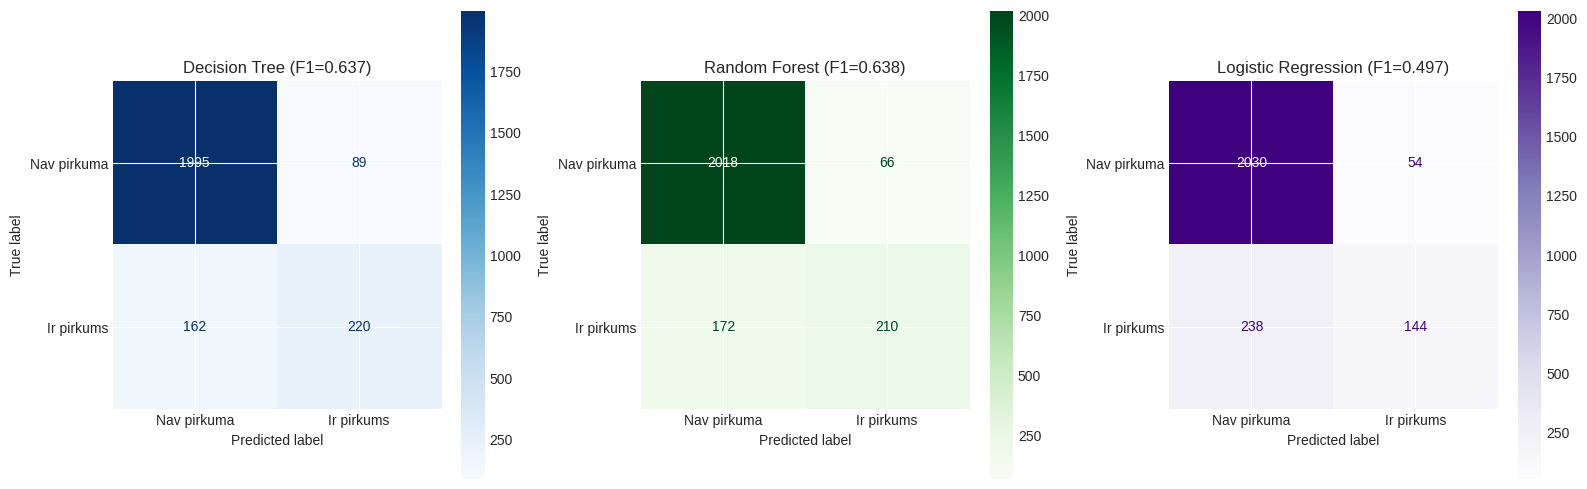

In [32]:
# 10.2 Confusion matrices blakus
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, dt_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Decision Tree (F1={dt_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title(f'Random Forest (F1={rf_f1:.3f})')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Nav pirkuma', 'Ir pirkums'],
    cmap='Purples', ax=axes[2]
)
axes[2].set_title(f'Logistic Regression (F1={lr_f1:.3f})')

plt.tight_layout()
plt.show()

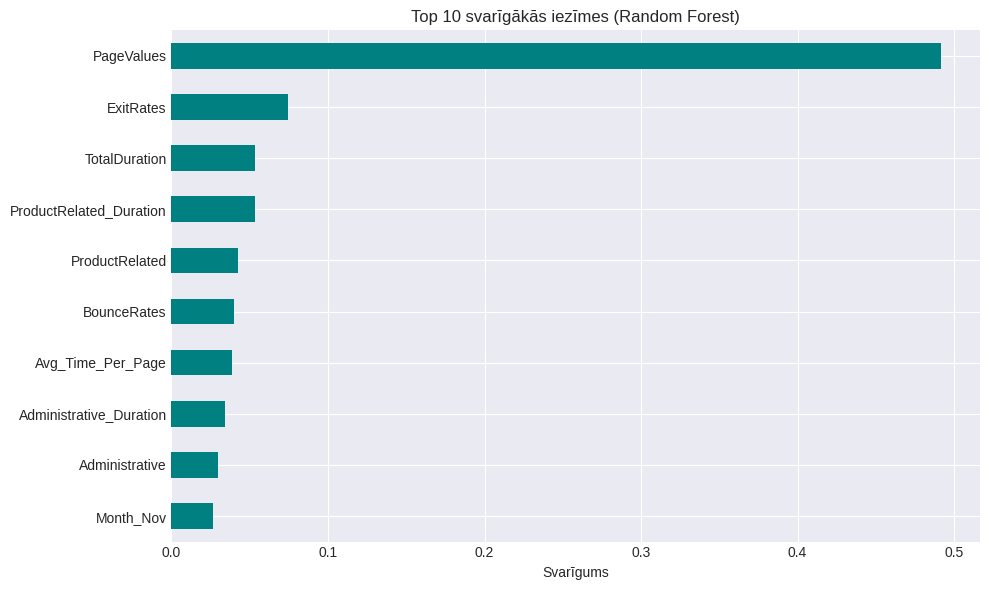

In [33]:
# 10.3 Feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (Random Forest)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 10.4 Secinājumi

**Modeļu salīdzinājums:**
Decision Tree ir labākais modelis (F1=0.632), Random Forest
ir gandrīz vienāds (F1=0.625), bet Logistic Regression ir
vājākais (F1=0.482). Logistic Regression neder šiem datiem,
jo meklē lineāru robežu, bet pircēju uzvedība nav lineāra.

**Kāpēc F1 score, nevis accuracy?**
Mūsu datos ir tikai 15.5% pircēju — nelīdzsvaroti dati.
Ja modelis vienmēr teiktu "nepirks" — accuracy būtu 84.5%,
bet modelis būtu bezjēdzīgs. F1 score ņem vērā gan
precision, gan recall — tāpēc ir godīgāks mērītājs!

**Svarīgākās iezīmes:**
PageValues ir absolūtais līderis (50% no lēmuma) —
ja klients atrodas augstvērtīgā lapā, viņš, visticamāk, pirks.
ExitRates un ProductRelated_Duration arī ir svarīgi —
cik ilgi klients skatās produktus un vai viņš aiziet.
Mūsu jaunā iezīme TotalDuration ir Top 4 —
Feature Engineering bija noderīgs! 😊

In [34]:
print("✓ Viss kārtībā — nav kļūdu!")

✓ Viss kārtībā — nav kļūdu!
